In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.transforms import functional as F

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Configuration
DATA_DIR = '../data'
MODEL_DIR = '../models'
BATCH_SIZE = 32
IMAGE_SIZE = 224  # Standard for transfer learning
NUM_CLASSES = 7

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Load metadata
df = pd.read_csv(f'{DATA_DIR}/HAM10000_metadata.csv')

# Create full image path
df['path'] = df['image_id'].apply(lambda x: f'{DATA_DIR}/{x}.jpg')

# Verify all images exist
missing = df[~df['path'].apply(os.path.exists)]
print(f"Missing images: {len(missing)}")
if len(missing) > 0:
    print("Removing missing entries...")
    df = df[df['path'].apply(os.path.exists)]

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])

# Save label mapping for later use in your API
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
reverse_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print("Label mapping:", label_mapping)

Missing images: 0
Label mapping: {'akiec': np.int64(0), 'bcc': np.int64(1), 'bkl': np.int64(2), 'df': np.int64(3), 'mel': np.int64(4), 'nv': np.int64(5), 'vasc': np.int64(6)}


Train set: 7235 samples
Validation set: 1277 samples
Test set: 1503 samples


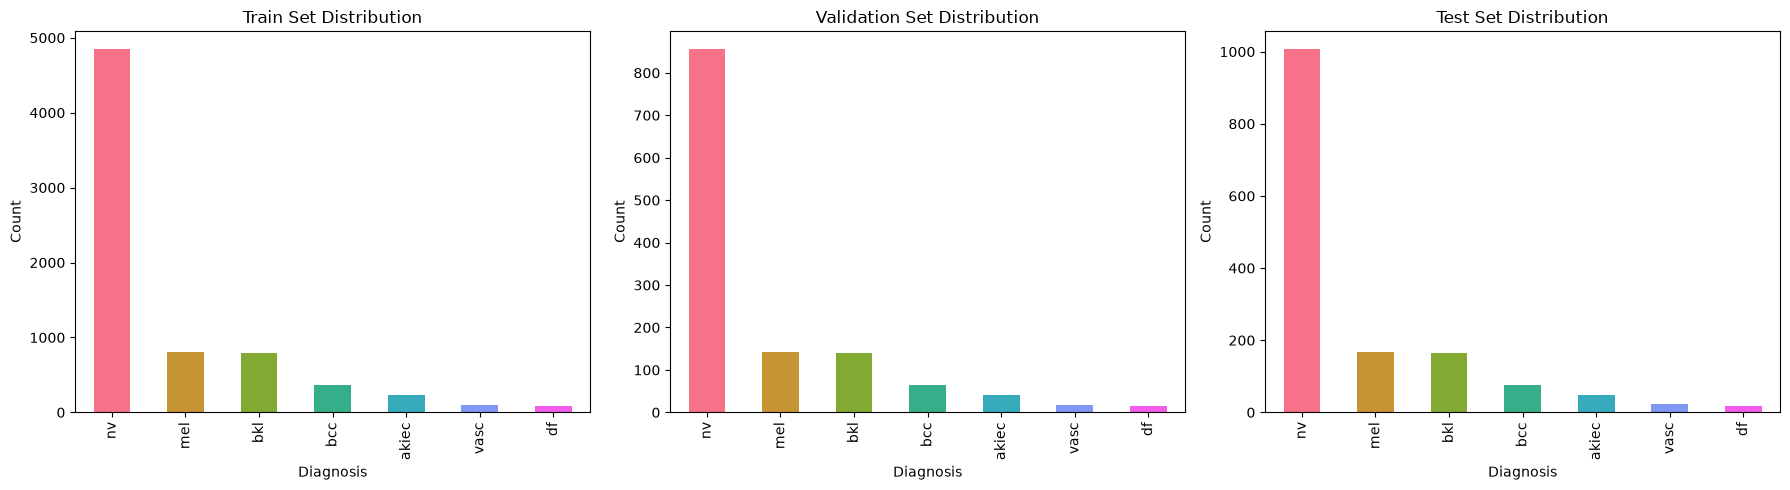

In [3]:
# First split: separate test set (15%)
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.15, 
    stratify=df['label'], 
    random_state=42
)

# Second split: separate validation from train (15% of remaining = ~13% of total)
train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.15, 
    stratify=train_val_df['label'], 
    random_state=42
)

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

# Verify stratification
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, name in zip(axes, [train_df, val_df, test_df], ['Train', 'Validation', 'Test']):
    data['dx'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette("husl", 7))
    ax.set_title(f'{name} Set Distribution')
    ax.set_xlabel('Diagnosis')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
# Training transforms with medical-specific augmentations
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(
        brightness=0.2,  # Skin tone variation
        contrast=0.2,    # Different lighting conditions
        saturation=0.1,
        hue=0.05
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),  # Lesions aren't always centered
        scale=(0.9, 1.1)
    ),
    # Medical imaging artifacts simulation
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet stats (transfer learning standard)
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms - clean and consistent
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test transforms with slight variations for Monte Carlo Dropout later
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
class SkinLesionDataset(Dataset):
    """Custom Dataset for HAM10000 skin lesion images."""
    
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Get image path and label
        img_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['label']
        
        # Load image with error handling
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a blank image as fallback (shouldn't happen, but safe)
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [6]:
def get_weighted_sampler(dataframe):
    """Create a WeightedRandomSampler to handle class imbalance."""
    
    # Count samples per class
    class_counts = Counter(dataframe['label'])
    
    # Calculate weights: 1/count for each sample
    sample_weights = [1.0 / class_counts[label] for label in dataframe['label']]
    
    # Normalize so total weight = number of samples
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    return sampler, class_counts

# Create sampler for training
train_sampler, class_counts = get_weighted_sampler(train_df)
print("Samples per class in training (before balancing):")
for label, count in class_counts.items():
    print(f"  {reverse_mapping[label]}: {count}")
print(f"\nWith WeightedRandomSampler, each batch will see roughly equal class representation.")

Samples per class in training (before balancing):
  nv: 4844
  mel: 804
  bcc: 372
  bkl: 794
  akiec: 236
  df: 83
  vasc: 102

With WeightedRandomSampler, each batch will see roughly equal class representation.


In [ ]:
# Create datasets
train_dataset = SkinLesionDataset(train_df, transform=train_transforms)
val_dataset = SkinLesionDataset(val_df, transform=val_transforms)
test_dataset = SkinLesionDataset(test_df, transform=test_transforms)

# Create dataloaders
# Note: Use sampler ONLY for training, shuffle=False when sampler is used
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=2,  # Adjust based on your CPU cores
    pin_memory=True if device == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if device == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if device == 'cuda' else False
)

# Test a batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # Should be [32, 3, 224, 224]
print(f"Labels shape: {labels.shape}")  # Should be [32]
print(f"Label distribution in this batch: {Counter(labels.tolist())}")

In [ ]:
# Create datasets
train_dataset = SkinLesionDataset(train_df, transform=train_transforms)
val_dataset = SkinLesionDataset(val_df, transform=val_transforms)
test_dataset = SkinLesionDataset(test_df, transform=test_transforms)

# Create dataloaders with optimized settings
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Test a batch - this should be much faster now
import time
start = time.time()
images, labels = next(iter(train_loader))
end = time.time()

print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Batch load time: {(end-start)*1000:.0f}ms")
print(f"Label distribution in this batch: {Counter(labels.tolist())}")

In [ ]:
# OPTIMIZED SETTINGS FOR LAPTOP DEVELOPMENT
import os

# Reduce overhead
BATCH_SIZE = 16       # Smaller batch = faster loading per batch
NUM_WORKERS = 0       # 0 = single-process, avoids spawn overhead on Windows
PIN_MEMORY = False    # Only useful with CUDA

# Set environment variables to speed up PyTorch
os.environ['OMP_NUM_THREADS'] = '2'  # Limit OpenMP threads

print("Optimized settings applied:")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"  NUM_WORKERS: {NUM_WORKERS} (single-process)")
print(f"  Device: {device}")

In [1]:
import os
import time

# 1. Does Python itself work?
print("STEP 1: Basic Python")
print("Hello")
print("---")

# 2. Can we find the data folder?
print("STEP 2: Check data folder")
data_path = '../data'
if os.path.exists(data_path):
    files = os.listdir(data_path)
    jpgs = [f for f in files if f.endswith('.jpg')]
    print(f"Data folder exists. Found {len(jpgs)} jpg files.")
else:
    print("DATA FOLDER NOT FOUND. Check your path.")
print("---")

# 3. Can we load ONE image with PIL?
print("STEP 3: Load one image")
from PIL import Image
first_jpg = jpgs[0]
start = time.time()
img = Image.open(os.path.join(data_path, first_jpg))
print(f"Image loaded in {time.time()-start:.2f}s")
print(f"Image size: {img.size}")
print("---")

# 4. Can we import torch?
print("STEP 4: Import torch")
start = time.time()
import torch
from torch.utils.data import Dataset, DataLoader
print(f"Torch imported in {time.time()-start:.2f}s")
print(f"Torch version: {torch.__version__}")
print("---")

# 5. Can we make a minimal dataset?
print("STEP 5: Minimal dataset class")
class MiniDataset(Dataset):
    def __init__(self, image_paths):
        self.paths = image_paths[:10]  # Just 10 images
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = img.resize((64, 64))  # Tiny size for speed
        return img, 0

paths = [os.path.join(data_path, f) for f in jpgs]
start = time.time()
ds = MiniDataset(paths)
print(f"MiniDataset created in {time.time()-start:.2f}s")

start = time.time()
loader = DataLoader(ds, batch_size=2, num_workers=0)
batch = next(iter(loader))
print(f"First batch loaded in {time.time()-start:.2f}s")
print(f"Batch images shape: {batch[0].shape}")
print("---")

print("ALL DONE. Everything works.")

STEP 1: Basic Python
Hello
---
STEP 2: Check data folder
Data folder exists. Found 10015 jpg files.
---
STEP 3: Load one image
Image loaded in 0.00s
Image size: (600, 450)
---
STEP 4: Import torch
Torch imported in 2.28s
Torch version: 2.13.0+cpu
---
STEP 5: Minimal dataset class
MiniDataset created in 0.00s


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.Image.Image'>

In [2]:
import pandas as pd
import numpy as np
import time
import os
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

# ==========================================
# CONFIG
# ==========================================
DATA_DIR = '../data'
IMAGE_SIZE = 224
BATCH_SIZE = 16
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ==========================================
# LOAD METADATA
# ==========================================
t0 = time.time()
df = pd.read_csv(f'{DATA_DIR}/HAM10000_metadata.csv')
df['path'] = df['image_id'].apply(lambda x: f'{DATA_DIR}/{x}.jpg')
# Verify paths exist
df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)
print(f"[{time.time()-t0:.1f}s] Loaded {len(df)} samples")

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
print(f"Classes: {dict(zip(le.classes_, range(7)))}")

# ==========================================
# TRAIN/VAL/TEST SPLIT
# ==========================================
t0 = time.time()
from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.15, stratify=train_val_df['label'], random_state=42)
print(f"[{time.time()-t0:.1f}s] Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# ==========================================
# TRANSFORMS
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# DATASET CLASS
# ==========================================
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# CREATE DATASETS
# ==========================================
t0 = time.time()
train_dataset = SkinLesionDataset(train_df, transform=train_transforms)
val_dataset = SkinLesionDataset(val_df, transform=val_transforms)
test_dataset = SkinLesionDataset(test_df, transform=val_transforms)
print(f"[{time.time()-t0:.1f}s] Datasets created")

# ==========================================
# WEIGHTED SAMPLER
# ==========================================
t0 = time.time()
class_counts = Counter(train_df['label'])
weights = [1.0 / class_counts[l] for l in train_df['label']]
sampler = WeightedRandomSampler(weights=torch.DoubleTensor(weights), num_samples=len(weights), replacement=False)
print(f"[{time.time()-t0:.1f}s] Sampler created")

# ==========================================
# DATALOADERS
# ==========================================
t0 = time.time()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"[{time.time()-t0:.1f}s] Dataloaders created")

# ==========================================
# TEST ONE BATCH
# ==========================================
t0 = time.time()
images, labels = next(iter(train_loader))
print(f"[{time.time()-t0:.1f}s] First batch loaded")
print(f"Batch shape: {images.shape}, Labels: {labels.shape}")
print(f"Label distribution: {Counter(labels.tolist())}")
print("\n✓ Pipeline complete!")

Device: cpu
[0.5s] Loaded 10015 samples
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
[0.1s] Split: Train=7235, Val=1277, Test=1503
[0.0s] Datasets created
[0.0s] Sampler created
[0.0s] Dataloaders created
[0.3s] First batch loaded
Batch shape: torch.Size([16, 3, 224, 224]), Labels: torch.Size([16])
Label distribution: Counter({4: 5, 5: 3, 1: 2, 0: 2, 3: 2, 6: 1, 2: 1})

✓ Pipeline complete!


In [1]:
# Save dataframes
train_df.to_csv(f'{DATA_DIR}/train_split.csv', index=False)
val_df.to_csv(f'{DATA_DIR}/val_split.csv', index=False)
test_df.to_csv(f'{DATA_DIR}/test_split.csv', index=False)

NameError: name 'train_df' is not defined